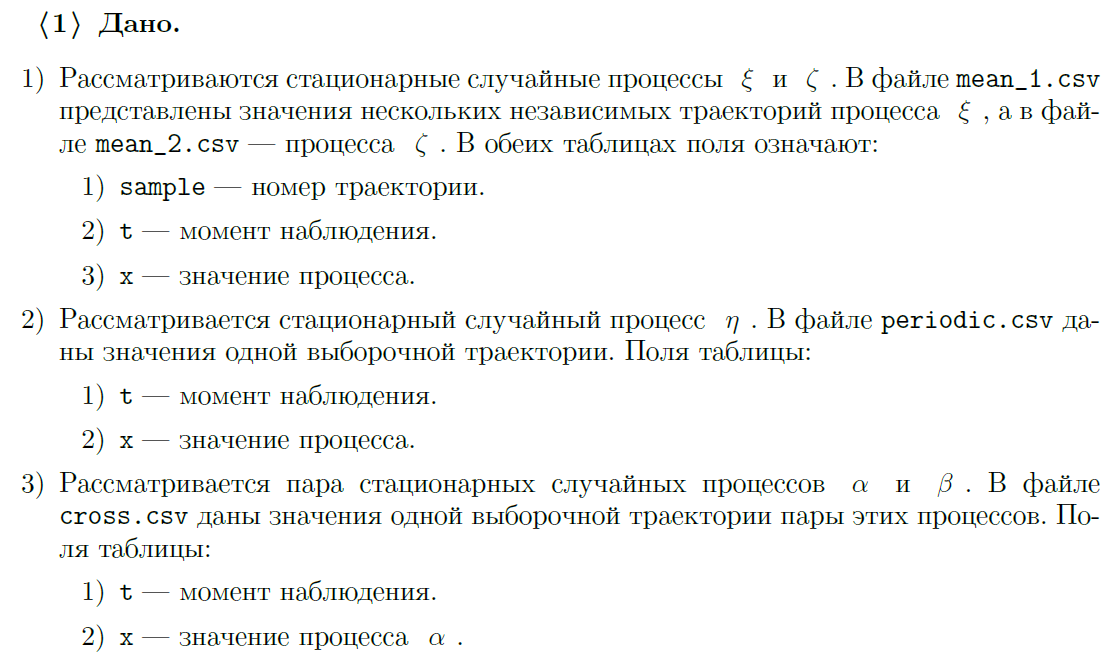

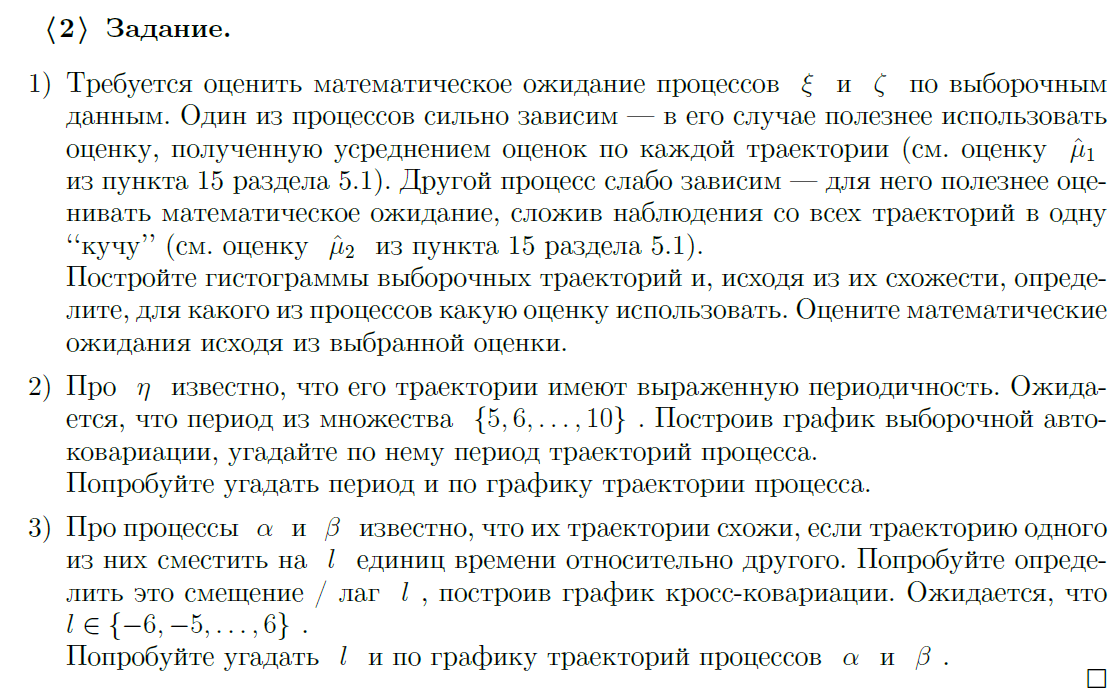

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
mean_1 = pd.read_csv('mean_1.csv')
mean_2 = pd.read_csv('mean_2.csv')


In [5]:

def draw_hists(X,bins):

    unique_samples = X['sample'].unique()
    num_rows = (len(unique_samples) + 2) // 3
    fig, axes = plt.subplots(num_rows, 3, figsize=(16, 4 * num_rows))
    axes = axes.flatten()

    for i, sample in enumerate(unique_samples):

        sample_data = X[X['sample'] == sample]
        axes[i].hist(sample_data['x'], bins, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'Гистограмма для sample = {sample}')
        axes[i].set_xlabel('x')
        axes[i].set_ylabel('Частота')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



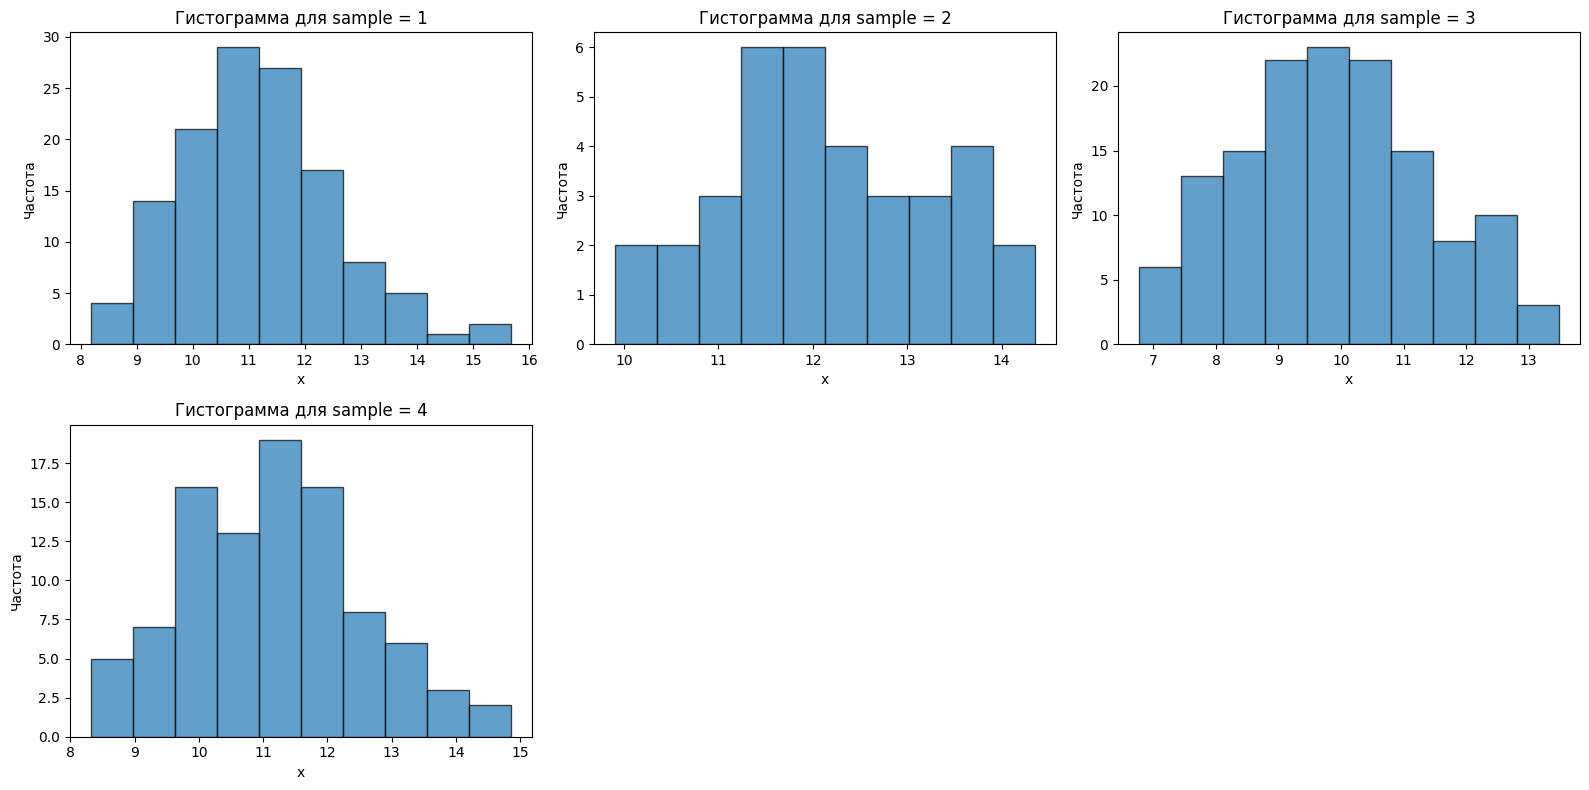

In [27]:
draw_hists(mean_1,10)

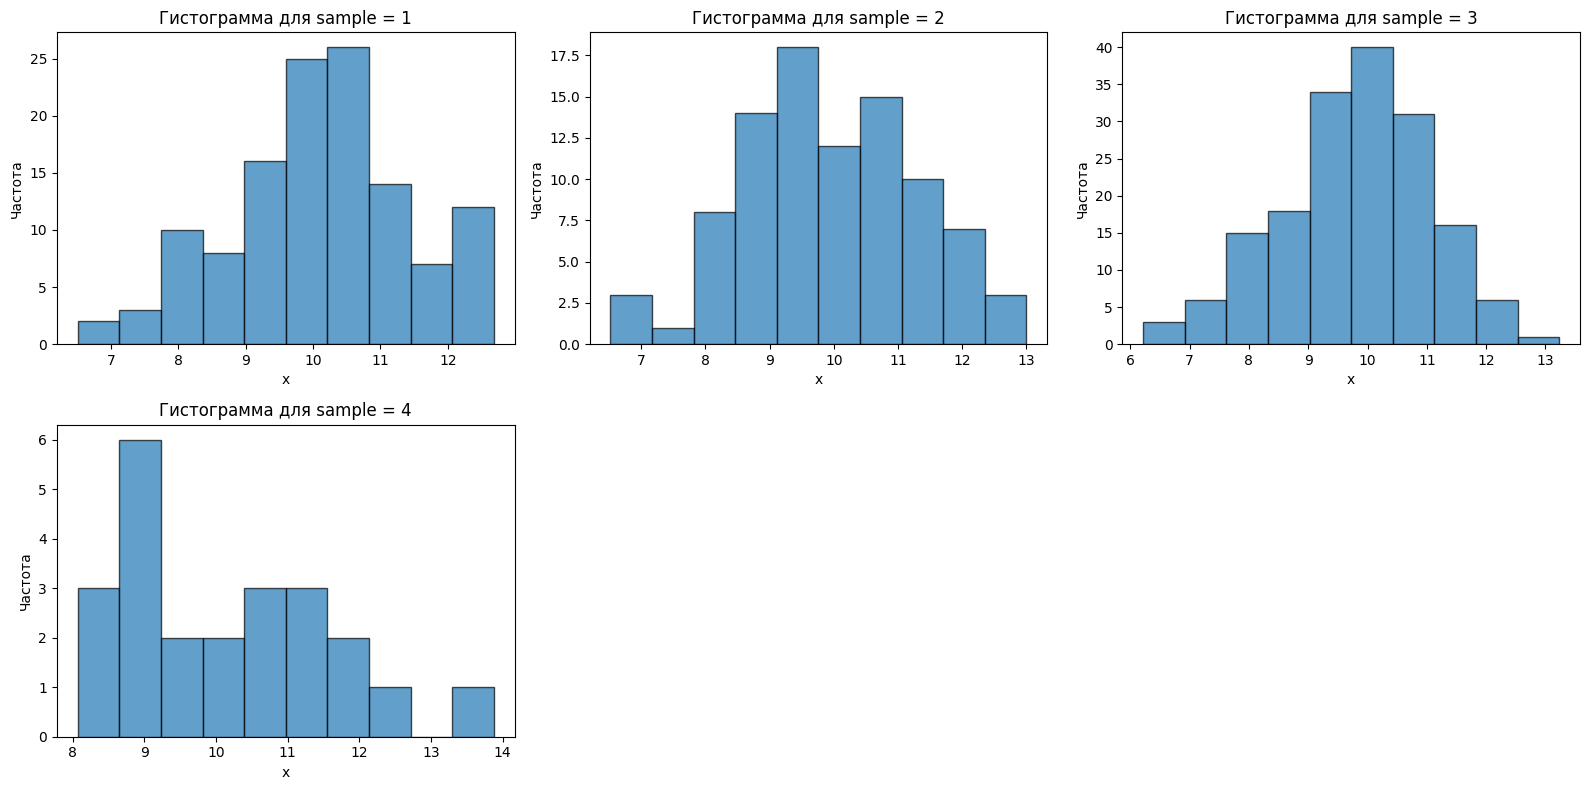

In [28]:
draw_hists(mean_2,10)

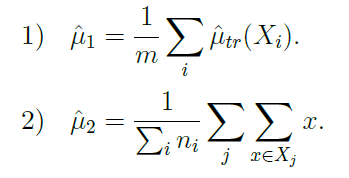

In [29]:
mu1 = mean_2.groupby('sample')['x'].mean().reset_index().mean()['x'] #Сильнозависимый
mu2 = mean_1['x'].mean()

print("mu1=",mu1)
print("mu2=",mu2)



mu1= 9.984588350940093
mu2= 10.797853090072525


## $\eta$
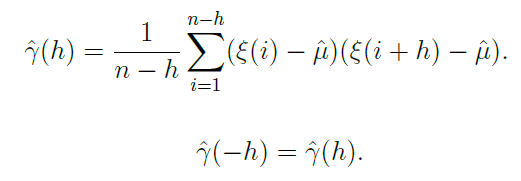

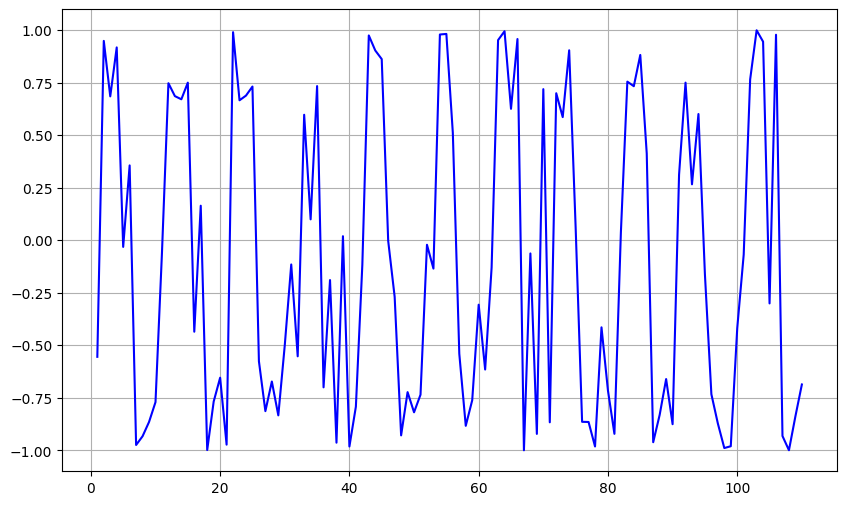

In [13]:
periodic = pd.read_csv('periodic.csv')
# Построение графика x от t
plt.figure(figsize=(10, 6))
plt.plot(periodic['t'], periodic['x'], label='x от t', color='blue')
plt.grid(True)
plt.show()

[ 1.          0.46115704  0.26876584 -0.25681077 -0.49902516 -0.64746451
 -0.48882607 -0.2723333   0.15461069  0.49533234  0.61790347  0.50072314
  0.17276778 -0.205961   -0.47413432 -0.58870572 -0.4749587  -0.1887446
  0.20020347  0.50854887  0.67547673  0.4902484   0.12820844 -0.22227889
 -0.53890715 -0.57590849 -0.48026824 -0.14602215  0.13472156  0.49542027
  0.532418    0.51427168  0.11583761 -0.17696476 -0.5383071  -0.55770392
 -0.47902789 -0.14825481  0.15795079  0.46779928  0.63854426  0.4940217
  0.10534772 -0.21872901 -0.53957005 -0.62411662 -0.38638625 -0.12543614
  0.28622947  0.4997799   0.59054793  0.43081565  0.10126783 -0.29633027
 -0.57246362 -0.55153922 -0.45173116 -0.0376827   0.25059448  0.50355974
  0.65130722  0.50344321  0.13455932 -0.27404853 -0.50936265 -0.75066338
 -0.3911078  -0.03974438  0.3080285   0.59670218  0.59821699  0.49904622
  0.11817631 -0.26580849 -0.61176854 -0.65876885 -0.52871733 -0.15763424
  0.21577695  0.56991792  0.74747869  0.58705479  0.1

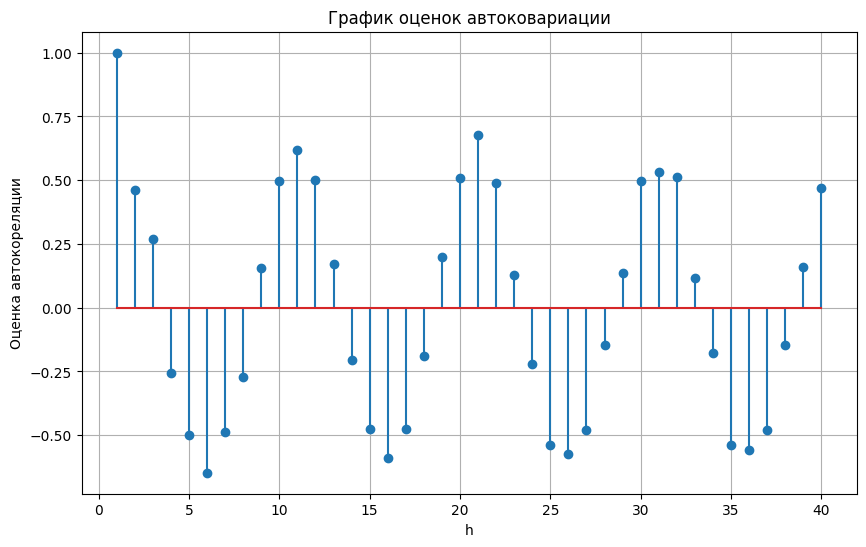

In [ ]:
def estimate_autocovariance(D,h):
    sum_terms = 0
    count = 0
    for i in range(len(D)):
        X_i = np.array(D[i])
        n_i = X_i.size
        for j in range(n_i - h):  # используем формулу, описанную выше
            sum_terms += (X_i[j] - X_i.mean()) * (X_i[j + h] - X_i.mean())
            count += 1
    gamma_h = (1 / count) * sum_terms
    return gamma_h

def estimate_autocovariance_vector(D, X):
    D = np.array(D)
    gamma_0 = estimate_autocovariance(D,0)

    gamma_h_vec = np.zeros(X.size)

    for h in range(X.size):
        gamma_h_vec[h] = estimate_autocovariance(D,h)
    return gamma_h_vec/gamma_0

gamma_h = estimate_autocovariance_vector([periodic['x']],periodic['x'])
print(f"{gamma_h}")

plt.figure(figsize=(10, 6))
plt.stem(periodic['t'][:40], gamma_h[:40])
# plt.plot(periodic['t'], gamma_h, marker='o', linestyle='-', color='b')
plt.title('График оценки автоковариации')
plt.xlabel('h')
plt.ylabel('Оценка автокореляции')
plt.grid(True)
plt.show()


Период - 10

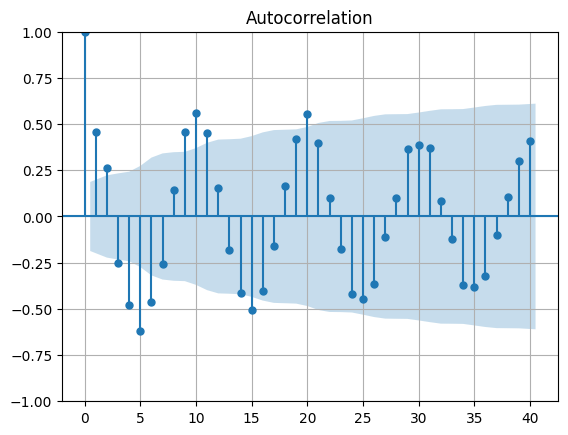

In [ ]:
# встроенная функция
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(periodic['x'], lags=40)
plt.grid(True)
plt.show()

## $\alpha$ и $\beta$

In [18]:
cross = pd.read_csv('cross.csv')

In [19]:
cross.shape

(98, 3)

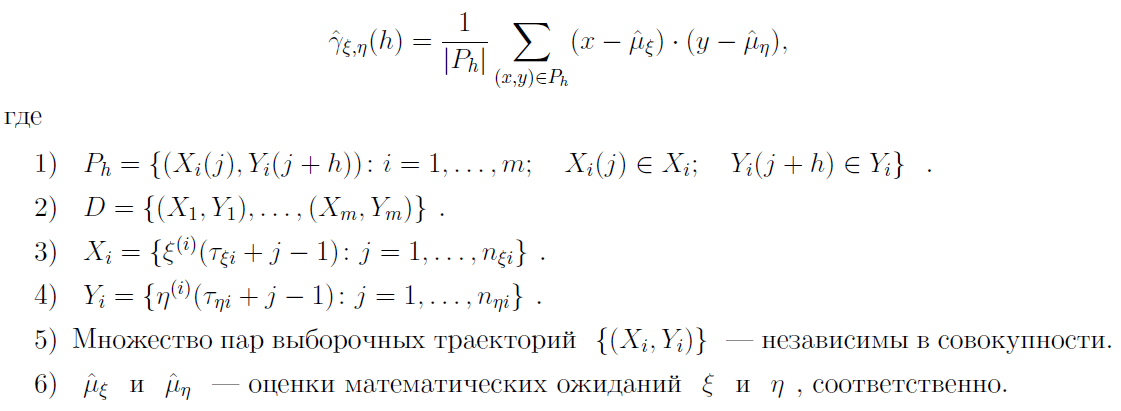

In [ ]:
def cross_covariance(x, y, max_lag):
    x = np.array(x)
    y = np.array(y)

    # Вычисляем математические ожидания
    mu_x = np.mean(x)
    mu_y = np.mean(y)

    x_centered = x - mu_x
    y_centered = y - mu_y

    # Вычисляем кросс-ковариацию
    lags = np.arange(-max_lag, max_lag + 1)
    cross_cov = np.array([np.sum(x_centered[:len(x)-lag] * y_centered[lag:]) if lag >= 0 else np.sum(x_centered[-lag:] * y_centered[:len(y)+lag]) for lag in lags])

    return lags, cross_cov

lags, cross_cov = cross_covariance(cross['x'],cross['y'],6)

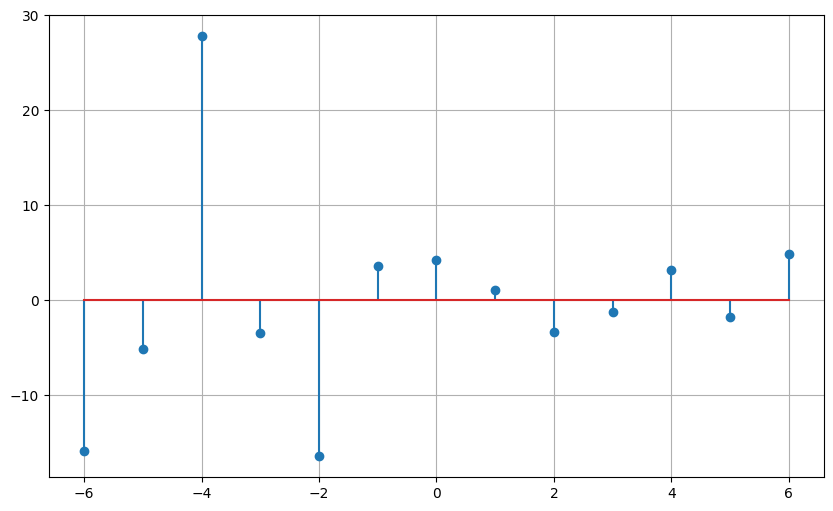

In [21]:
plt.figure(figsize=(10, 6))
plt.stem(lags,cross_cov)
plt.grid(True)
plt.show()

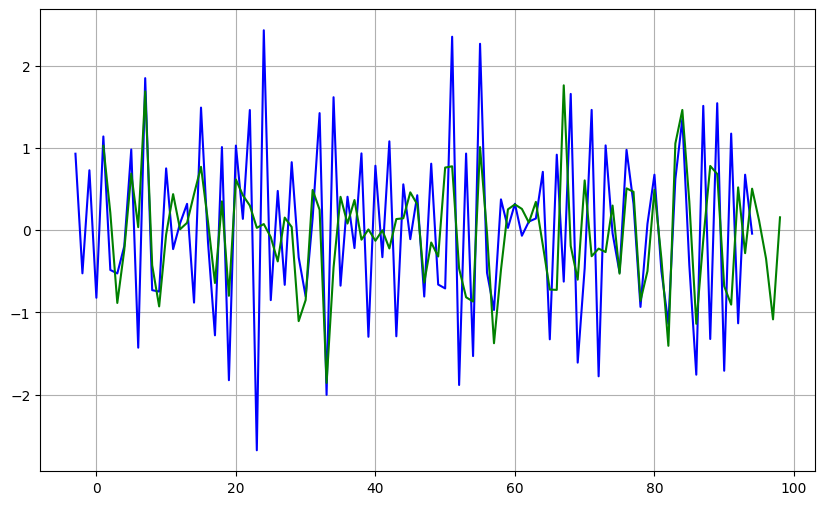

In [26]:
# проверим:
cross_cut = cross
cross_cut['t_shifted'] = cross_cut['t'] - 4

plt.figure(figsize=(10, 6))
plt.plot(cross_cut['t_shifted'], cross_cut['x'], label='x от t', color='blue')
plt.plot(cross_cut['t'], cross_cut['y'], label='y от t', color='green')
plt.grid(True)
plt.show()